In [58]:
import pandas as pd


In [59]:
df = pd.read_csv("/workspaces/Data_Science_Internship/Week_4/Dataset/Mall_Customers2.csv")

In [60]:
df.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


In [61]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 7 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   CustomerID              200 non-null    int64
 1   Gender                  200 non-null    str  
 2   Age                     200 non-null    int64
 3   Annual Income (k$)      200 non-null    int64
 4   Spending Score (1-100)  200 non-null    int64
 5   City                    200 non-null    str  
 6   Customer_Level          200 non-null    str  
dtypes: int64(4), str(3)
memory usage: 11.1 KB


In [62]:
missing = df.isnull().sum()
missing

CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
City                      0
Customer_Level            0
dtype: int64

In [63]:
X_raw = df[['Age','Annual Income (k$)','Spending Score (1-100)']]

In [64]:
features = ['Age','Annual Income (k$)','Spending Score (1-100)']
X = df[features]

In [65]:
from sklearn.model_selection import train_test_split 
X_train , X_test = train_test_split(
    X,
    test_size = 0.3,
    random_state = 42
)

In [66]:
print(X_train.shape)
print(X_test.shape)

(140, 3)
(60, 3)


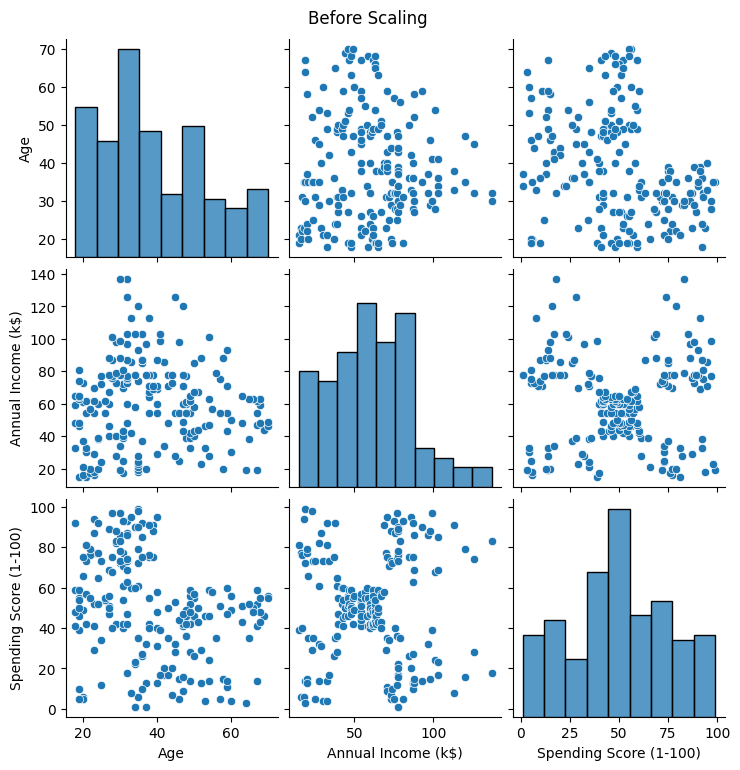

In [67]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.pairplot(X)
plt.suptitle('Before Scaling ', y =1.02)
plt.show()

In [68]:
from sklearn.preprocessing import  StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_scaled = pd.DataFrame(X_scaled,columns = features)

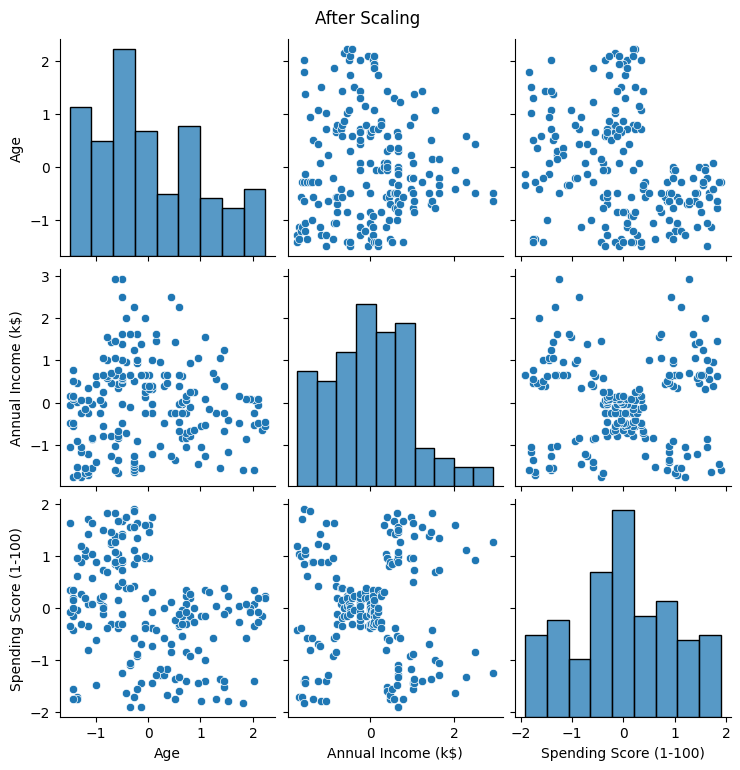

In [69]:
sns.pairplot(X_scaled)
plt.suptitle('After Scaling ', y =1.02)
plt.show()

In [70]:
from sklearn.cluster import  KMeans


In [71]:
k_means_raw =KMeans(n_clusters = 5, random_state = 42)
labels_raw = k_means_raw.fit_predict(X_raw)

inertia_raw = k_means_raw.inertia_

In [72]:
k_means_scaled =KMeans(n_clusters = 5, random_state = 42)
labels_scaled = k_means_scaled.fit_predict(X_scaled)

inertia_scaled = k_means_scaled.inertia_

In [73]:
print("inertia(Before Scaling):",inertia_raw)
print("inertia(After Scaling):",inertia_scaled)

inertia(Before Scaling): 97211.84353980474
inertia(After Scaling): 169.89149793438568


In [74]:
from sklearn.metrics import silhouette_score


In [75]:
silhouette_raw = silhouette_score(X_raw,labels_raw)
silhouette_scaled = silhouette_score(X_scaled,labels_scaled)

In [76]:
print("Silhouette Score(Before Scaling):",silhouette_raw)
print("Silhouette Score(After Scaling):",silhouette_scaled)

Silhouette Score(Before Scaling): 0.3575963460506624
Silhouette Score(After Scaling): 0.40846873777345605


In [77]:
df['Customer_Level']

0       Low
1      High
2       Low
3      High
4       Low
       ... 
195    High
196     Low
197    High
198     Low
199    High
Name: Customer_Level, Length: 200, dtype: str

In [78]:
from sklearn.preprocessing import OrdinalEncoder

oe = OrdinalEncoder(categories=[['Low', 'Medium', 'High']])
df['Customer_Level_encoded'] = oe.fit_transform(df[['Customer_Level']])
df['Customer_Level_encoded']

0      0.0
1      2.0
2      0.0
3      2.0
4      0.0
      ... 
195    2.0
196    0.0
197    2.0
198    0.0
199    2.0
Name: Customer_Level_encoded, Length: 200, dtype: float64

In [79]:
df['Gender']

0        Male
1        Male
2      Female
3      Female
4      Female
        ...  
195    Female
196    Female
197      Male
198      Male
199      Male
Name: Gender, Length: 200, dtype: str

In [80]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df['Gender_Encoded'] = le.fit_transform(df['Gender'])
df['Gender_Encoded']

0      1
1      1
2      0
3      0
4      0
      ..
195    0
196    0
197    1
198    1
199    1
Name: Gender_Encoded, Length: 200, dtype: int64

In [81]:
df_encoded = pd.get_dummies(df,columns=['City'],drop_first=True)
df_encoded

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),Customer_Level,Customer_Level_encoded,Gender_Encoded,City_Delhi,City_Mumbai
0,1,Male,19,15,39,Low,0.0,1,True,False
1,2,Male,21,15,81,High,2.0,1,False,True
2,3,Female,20,16,6,Low,0.0,0,True,False
3,4,Female,23,16,77,High,2.0,0,False,False
4,5,Female,31,17,40,Low,0.0,0,False,True
...,...,...,...,...,...,...,...,...,...,...
195,196,Female,35,120,79,High,2.0,0,True,False
196,197,Female,45,126,28,Low,0.0,0,False,True
197,198,Male,32,126,74,High,2.0,1,True,False
198,199,Male,32,137,18,Low,0.0,1,False,False


In [82]:
df.columns

Index(['CustomerID', 'Gender', 'Age', 'Annual Income (k$)',
       'Spending Score (1-100)', 'City', 'Customer_Level',
       'Customer_Level_encoded', 'Gender_Encoded'],
      dtype='str')

In [83]:
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),City,Customer_Level,Customer_Level_encoded,Gender_Encoded
0,1,Male,19,15,39,Delhi,Low,0.0,1
1,2,Male,21,15,81,Mumbai,High,2.0,1
2,3,Female,20,16,6,Delhi,Low,0.0,0
3,4,Female,23,16,77,Bangalore,High,2.0,0
4,5,Female,31,17,40,Mumbai,Low,0.0,0


In [84]:
df['Age_Group'] = pd.cut(
    df['Age'],
    bins=[0, 25, 40, 60, 100],
    labels=['Young', 'Adult', 'Mid_Age', 'Senior']
)

In [85]:
df['Income_Group'] = pd.cut(
    df['Annual Income (k$)'],
    bins=[0, 30, 60 ,100, df['Annual Income (k$)'].max()],
    labels=['Low', 'Medium', 'High', 'Very_High']
)

In [86]:
max(df['Annual Income (k$)'])

137

In [87]:
min(df['Annual Income (k$)'])

15

In [88]:
df['Spending_Category'] = pd.cut(
    df['Spending Score (1-100)'],
    bins=[0, 40, 70, 100],
    labels=['Low_Spender', 'Medium_Spender', 'High_Spender']
)

In [89]:
def value_segment(row):
    if row['Annual Income (k$)'] > 70 and row['Spending Score (1-100)'] > 70:
        return 'Premium'
    elif row['Annual Income (k$)'] > 70:
        return 'Potential'
    else:
        return 'Regular'

df['Customer_Value_Segment'] = df.apply(value_segment, axis=1)

In [90]:
df_encoded = pd.get_dummies(
    df,
    columns=[
        'Gender',
        'City',
        'Customer_Level',
        'Age_Group',
        'Income_Group',
        'Spending_Category',
        'Customer_Value_Segment'
    ],
    drop_first=True
)

In [91]:
print("Before feature engineering:", df.shape)
print("After feature engineering:", df_encoded.shape)

Before feature engineering: (200, 13)
After feature engineering: (200, 21)


In [92]:
id_col = df_encoded[['CustomerID']]
features_df = df_encoded.drop(columns=['CustomerID'])

In [93]:
corr_matrix = features_df.corr()
corr_matrix

,Age,Annual Income (k$),Spending Score (1-100),Customer_Level_encoded,Gender_Encoded,Gender_Male,City_Delhi,City_Mumbai,Customer_Level_Low,Customer_Level_Medium,Age_Group_Adult,Age_Group_Mid_Age,Age_Group_Senior,Income_Group_Medium,Income_Group_High,Income_Group_Very_High,Spending_Category_Medium_Spender,Spending_Category_High_Spender,Customer_Value_Segment_Premium,Customer_Value_Segment_Regular
Age,1.000000,-0.012398,-0.327227,-0.315043,0.060867,0.060867,0.029299,0.002930,0.158708,0.188949,-0.353629,0.534773,0.608024,0.172391,-0.052626,-0.037832,0.188949,-0.375759,-0.189529,0.117356
Annual Income (k$),-0.012398,1.000000,0.009903,-0.004739,0.056410,0.056410,-0.021348,0.009427,0.091505,-0.165189,0.277618,0.011126,-0.122851,-0.351877,0.516239,0.567095,-0.165189,0.087591,0.441419,-0.786846
Spending Score (1-100),-0.327227,0.009903,1.000000,0.933209,-0.058109,-0.058109,-0.000396,-0.008321,-0.791281,0.045856,0.365438,-0.424636,-0.071273,-0.000083,0.014625,-0.015063,0.045856,0.777027,0.580158,0.000322
Customer_Level_encoded,-0.315043,-0.004739,0.933209,1.000000,-0.040105,-0.040105,-0.005347,-0.005347,-0.848181,0.049640,0.328782,-0.416105,-0.052481,-0.000418,0.025857,-0.035162,0.049640,0.832361,0.608401,0.009088
Gender_Encoded,0.060867,0.056410,-0.058109,-0.040105,1.000000,1.000000,0.098693,-0.086356,0.027756,0.009813,-0.040001,-0.062133,0.127137,-0.086544,0.107143,-0.045795,0.009813,-0.039932,-0.014111,-0.092632
Gender_Male,0.060867,0.056410,-0.058109,-0.040105,1.000000,1.000000,0.098693,-0.086356,0.027756,0.009813,-0.040001,-0.062133,0.127137,-0.086544,0.107143,-0.045795,0.009813,-0.039932,-0.014111,-0.092632
City_Delhi,0.029299,-0.021348,-0.000396,-0.005347,0.098693,0.098693,1.000000,-0.666667,-0.026366,0.057999,0.008272,-0.119706,0.153707,0.013023,-0.004112,-0.024001,0.057999,-0.036782,-0.005499,0.012684
City_Mumbai,0.002930,0.009427,-0.008321,-0.005347,-0.086356,-0.086356,-0.666667,1.000000,0.017577,-0.024857,-0.095123,0.168475,-0.102471,-0.008682,-0.004112,0.016001,-0.024857,0.009196,-0.005499,-0.008456
Customer_Level_Low,0.158708,0.091505,-0.791281,-0.848181,0.027756,0.027756,-0.026366,0.017577,1.000000,-0.571158,-0.140885,0.298901,-0.090895,-0.292783,0.092810,0.109264,-0.571158,-0.412411,-0.301445,-0.305212
Customer_Level_Medium,0.188949,-0.165189,0.045856,0.049640,0.009813,0.009813,0.057999,-0.024857,-0.571158,1.000000,-0.243845,0.081220,0.252709,0.552692,-0.215062,-0.151531,1.000000,-0.512232,-0.374408,0.561398


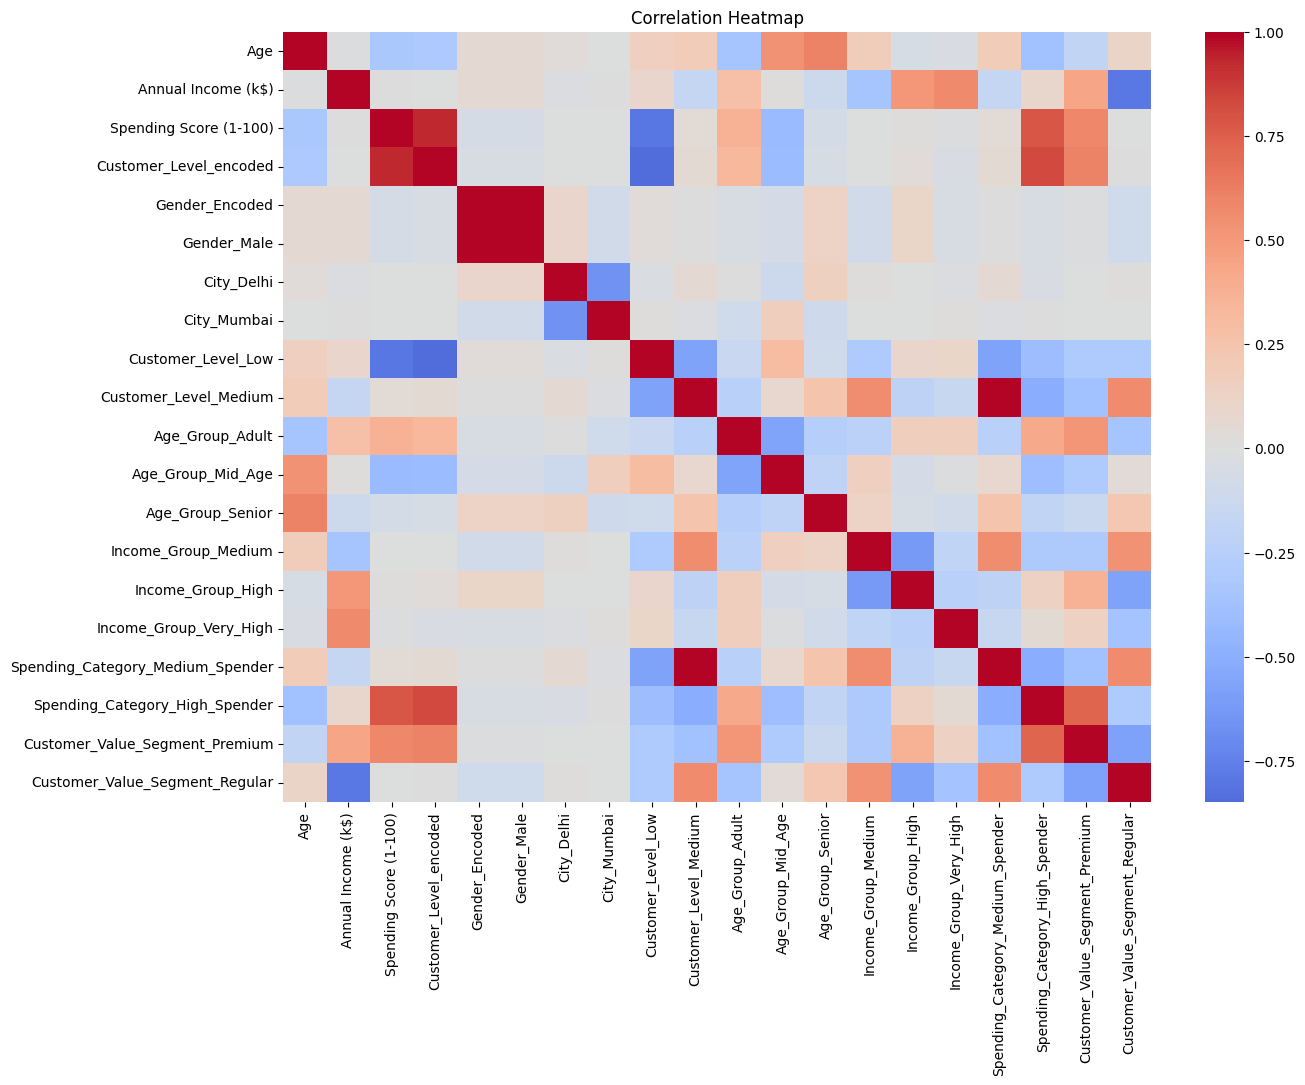

In [94]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(14,10))
sns.heatmap(corr_matrix, cmap='coolwarm', center=0)
plt.title("Correlation Heatmap")
plt.show()

In [95]:
import numpy as np
upper_tri = corr_matrix.abs().where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)

to_drop = [
    column for column in upper_tri.columns
    if any(upper_tri[column] > 0.85)
]

print("Highly correlated features to drop:", to_drop)

Highly correlated features to drop: ['Customer_Level_encoded', 'Gender_Male', 'Spending_Category_Medium_Spender']


In [96]:
features_selected = features_df.drop(columns=to_drop)

In [97]:
from sklearn.feature_selection import VarianceThreshold

selector = VarianceThreshold(threshold=0.01)
features_var = selector.fit_transform(features_selected)

selected_columns = features_selected.columns[selector.get_support()]
features_selected = pd.DataFrame(
    features_var,
    columns=selected_columns
)

In [98]:
final_df = pd.concat([id_col.reset_index(drop=True),
                      features_selected.reset_index(drop=True)],
                     axis=1)

In [99]:
print("Before feature selection:", df_encoded.shape)
print("After feature selection:", final_df.shape)

Before feature selection: (200, 21)
After feature selection: (200, 18)


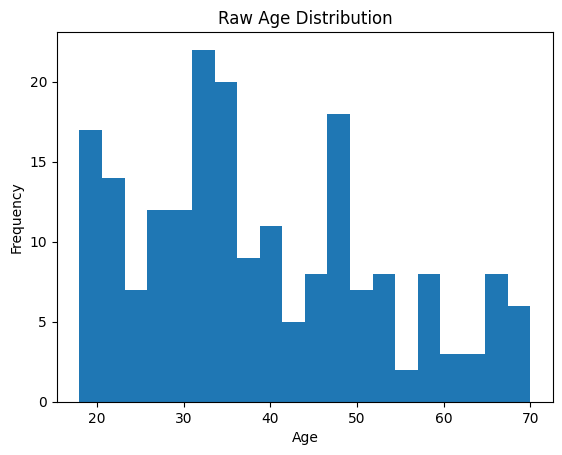

In [100]:
import matplotlib.pyplot as plt

plt.figure()
plt.hist(df['Age'], bins=20)
plt.title("Raw Age Distribution")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()

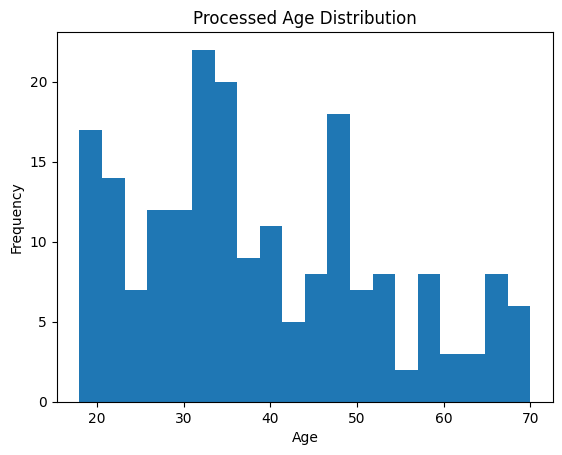

In [101]:
plt.figure()
plt.hist(df_encoded['Age'], bins=20)
plt.title("Processed Age Distribution")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()

In [102]:
print(df_encoded.columns.tolist())

['CustomerID', 'Age', 'Annual Income (k$)', 'Spending Score (1-100)', 'Customer_Level_encoded', 'Gender_Encoded', 'Gender_Male', 'City_Delhi', 'City_Mumbai', 'Customer_Level_Low', 'Customer_Level_Medium', 'Age_Group_Adult', 'Age_Group_Mid_Age', 'Age_Group_Senior', 'Income_Group_Medium', 'Income_Group_High', 'Income_Group_Very_High', 'Spending_Category_Medium_Spender', 'Spending_Category_High_Spender', 'Customer_Value_Segment_Premium', 'Customer_Value_Segment_Regular']
